# Your AI agent is an absorbing Markov chain

This notebook connects the series to a system I spend my working days
with. If you arrived here without notebooks 01 and 02, read
those first; this one leans on the fundamental matrix throughout.

First, what a pipeline agent is, for readers who have not built one. A
common way to automate a task with a large language model is to break
the task into a fixed sequence of steps and make one model call per
step. A concrete example, borrowed from my companion repository
[agent-failure-lab](https://github.com/netsatsawat/agent-failure-lab):
an expense-report agent that reads a folder of receipts and produces a
summary. Its steps are extract the line items, parse the dates,
categorize each expense, look up exchange rates, convert currencies,
sum by category, sanity-check the totals, and write the report. Eight
steps, eight model calls, each one imperfect.

Imperfect is the operative word. A model call can return malformed
output, hallucinate a value, or botch arithmetic. Say each step
succeeds with some probability. Then the whole run is a process moving
through states ("working on step 3") until it hits one of two ends it
never leaves: **task completed** or **task failed**.

That sentence should sound familiar. It is notebook 02's loan book
wearing a lanyard. Steps are transient states, the two outcomes are
absorbing states, and the mitigations teams bolt on (retries,
verification) are edits to the transition probabilities. The
agent-failure-lab repository measures all of this empirically, with
simulations and a real local model. Here we derive its headline numbers
with the fundamental matrix instead, then use the chain view to answer
questions the simple algebra cannot reach: where failing runs die,
which step deserves the improvement budget, and what happens when the
pipeline grows a branch.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from markov import AbsorbingChain

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, GRAY, INK = '#fab219', '#d03b3b', '#8a8f98', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

def pipeline_chain(step_probs):
    """Absorbing chain for a straight pipeline.

    One transient state per step. Success moves to the next step (or to
    'done' from the last one); failure moves to 'failed'. Both endings
    are absorbing.
    """
    n = len(step_probs)
    states = [f'step{i+1}' for i in range(n)] + ['done', 'failed']
    P = np.zeros((n + 2, n + 2))
    for i, p in enumerate(step_probs):
        nxt = n if i == n - 1 else i + 1
        P[i, nxt] = p
        P[i, n + 1] = 1 - p
    P[n, n] = 1.0
    P[n + 1, n + 1] = 1.0
    return AbsorbingChain(P, states)

## Start by hand, as always

Three steps, each succeeding 85% of the time, failures independent.
The run finishes only if every step succeeds, so the chance is
$0.85 \times 0.85 \times 0.85 \approx 0.614$. Multiplication is
doing all the work, and one modeling assumption deserves its moment:
we treat each step's success as independent of how earlier steps went,
given that the run reached it. Real failures can be correlated (a bad
document poisons several steps at once; the lab's live runs discuss
this), but independence is the honest baseline to start from.

The by-hand method already reveals the industry's core problem. Watch
what happens to that product as pipelines get longer, at per-step
accuracies that all sound reassuring.

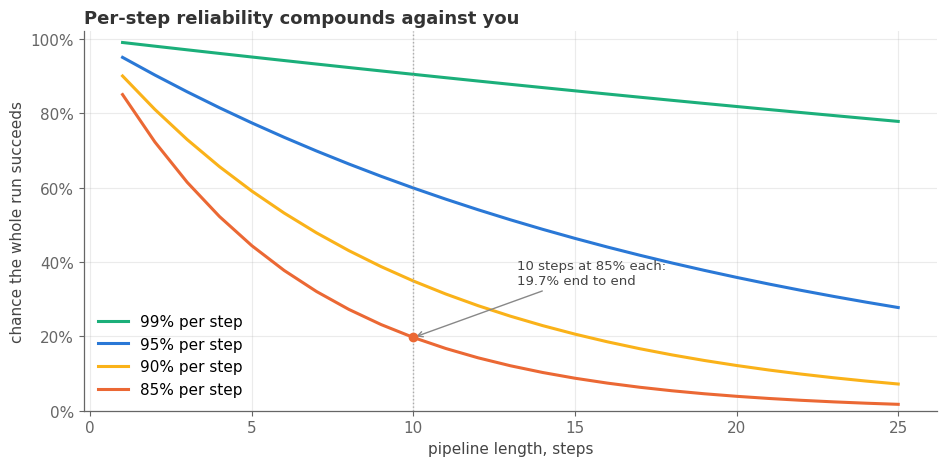

In [2]:
steps = np.arange(1, 26)

fig, ax = plt.subplots(figsize=(9.6, 4.8))
for p_, color in ((0.99, GREEN), (0.95, BLUE), (0.90, AMBER), (0.85, ORANGE)):
    ax.plot(steps, 100 * p_ ** steps, lw=2.2, color=color,
            label=f'{p_:.0%} per step')
ax.axvline(10, color='#aaaaaa', ls=':', lw=1)
ax.scatter([10], [100 * 0.85 ** 10], color=ORANGE, zorder=5)
ax.annotate('10 steps at 85% each:\n19.7% end to end',
            xy=(10, 100 * 0.85 ** 10), xytext=(13.2, 34),
            fontsize=9.5, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 102)
ax.set_xlabel('pipeline length, steps')
ax.set_ylabel('chance the whole run succeeds')
ax.set_title('Per-step reliability compounds against you')
ax.legend()
fig.tight_layout()

An 85% model, which sounds like a solid B grade, delivers a one-in-five
agent at ten steps. Even the 95% curve is down near 28% by step 25.
This compounding is the entire reason agent reliability is a field.

## The same number from the chain

Multiplication answered that question in one line, so why drag in the
machinery of notebook 02? Because multiplication only works while the
pipeline is a straight line and the question is "did everything
succeed". The chain formulation answers a whole family of questions,
keeps working when the pipeline branches, and prices the journey, not
just the destination. The translation table:

| Pipeline concept | Chain concept |
|---|---|
| working on step $i$ | transient state $i$ |
| task completed / task failed | the two absorbing states |
| per-step success rate | transition probabilities |
| end-to-end success rate | absorption probability into "done", from $B = NR$ |
| expected model calls per run | visit counts from $N$, priced like notebook 02's loan costs |

The lab's baseline scenario is ten steps at 85% with no mitigation.
Its published end-to-end number is 19.7%. The chain does not know the
closed form $p^n$; it only knows how to invert $I - Q$. They had better
agree.

In [3]:
p, n = 0.85, 10
chain = pipeline_chain([p] * n)
B = chain.absorption_probabilities()

success = B[0, chain.absorbing_states.index('done')]
print(f"absorption into 'done' from step 1: {success:.4f}")
print(f"closed form p**n                  : {p**n:.4f}")
assert abs(success - p**n) < 1e-12

absorption into 'done' from step 1: 0.1969
closed form p**n                  : 0.1969


## Mitigations are edits to the transition matrix

Nobody ships the baseline. The two standard mitigations, and what each
does to the numbers:

**Retry.** Some failures announce themselves: the output violates the
schema, a tool call errors out. Code can catch those and simply run the
step again, once. The step now fails only if both attempts fail, so its
effective success rate rises from $p$ to $1 - (1-p)^2$. At $p = 0.85$
that is $1 - 0.15^2 = 0.9775$. One caveat the lab's live experiments
hammer home: silent failures, a wrong number in valid JSON, trigger no
retry. This model treats every failure as retryable, which makes retry
look as good as it can possibly look.

**Verify.** Add a second model call after each step to review the
step's output, and redo the step once if the reviewer objects. The
reviewer is imperfect too; give it recall $r$, the fraction of true
failures it catches (the lab uses $r = 0.9$). A step now succeeds
directly ($p$), or fails ($1-p$), gets caught ($r$), and the redo
succeeds ($p$): effective rate $p + (1-p) \, r \, p \approx 0.9648$
at our numbers.

Both mitigations are, from the chain's point of view, nothing but
edits to the transition probabilities before the matrix is built. The
structure of the chain is untouched.

Cost rides along naturally. Expected model calls per step: retry pays
$1 + (1-p)$ calls (a second only on failure), verify pays
$2 + (1-p) \, r$ (the reviewer always runs, the redo only on a
catch). One wrinkle: when failures are detectable, a production
pipeline halts on the ones it cannot fix, so its expected cost comes
from the chain's visit counts. The lab instead reports the cost of its
experimental setup, where every step always executes. The code below
computes both, and asserts the lab's published table rather than
assuming it.

In [4]:
r = 0.9   # verifier recall used in the lab

def effective_p(p, mode):
    return {'none': p,
            'retry': 1 - (1 - p) ** 2,
            'verify': p + (1 - p) * r * p}[mode]

def calls_per_step(p, mode):
    return {'none': 1.0,
            'retry': 1 + (1 - p),
            'verify': 2 + (1 - p) * r}[mode]

rows = []
for mode in ('none', 'verify', 'retry'):
    pe = effective_p(p, mode)
    c = pipeline_chain([pe] * n)
    e2e = c.absorption_probabilities()[0, c.absorbing_states.index('done')]
    rows.append((mode, pe, e2e, n * calls_per_step(p, mode),
                 c.expected_cost([calls_per_step(p, mode)] * n)[0]))

table = pd.DataFrame(rows, columns=['mitigation', 'per-step rate',
                                    'end-to-end success',
                                    'calls, lab semantics',
                                    'calls, halting pipeline'])
table = table.set_index('mitigation')
display(table.round(3))

assert abs(table.loc['none', 'end-to-end success'] - 0.197) < 5e-4
assert abs(table.loc['verify', 'end-to-end success'] - 0.698) < 5e-4
assert abs(table.loc['retry', 'end-to-end success'] - 0.796) < 5e-4
assert abs(table.loc['none', 'calls, lab semantics'] - 10.0) < 0.05
assert abs(table.loc['verify', 'calls, lab semantics'] - 21.4) < 0.05
assert abs(table.loc['retry', 'calls, lab semantics'] - 11.5) < 0.05
print("all six of the lab's published numbers reproduced")

,per-step rate,end-to-end success,"calls, lab semantics","calls, halting pipeline"
mitigation,,,,
none,0.850,0.197,10.00,5.354
verify,0.965,0.698,21.35,18.263
retry,0.978,0.796,11.50,10.403


all six of the lab's published numbers reproduced


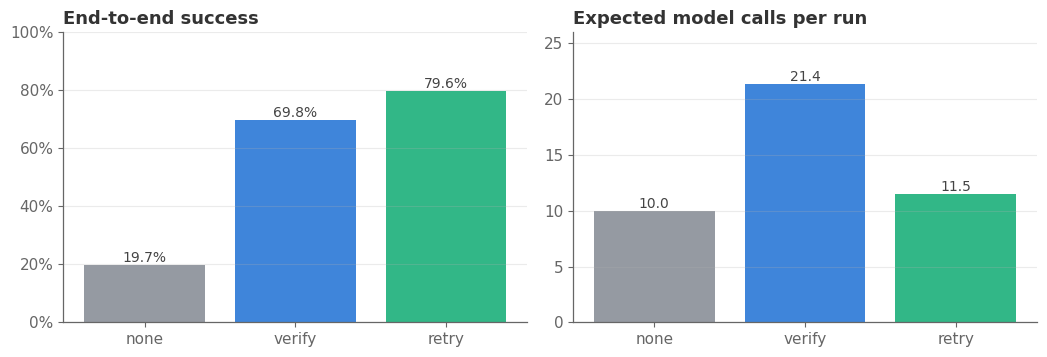

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.7))
modes = ['none', 'verify', 'retry']
colors = [GRAY, BLUE, GREEN]

bars = axes[0].bar(modes, 100 * table['end-to-end success'], color=colors,
                   alpha=0.9)
axes[0].bar_label(bars, fmt='%.1f%%', fontsize=10, color='#444444')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_ylim(0, 100)
axes[0].set_title('End-to-end success')

bars = axes[1].bar(modes, table['calls, lab semantics'], color=colors,
                   alpha=0.9)
axes[1].bar_label(bars, fmt='%.1f', fontsize=10, color='#444444')
axes[1].set_ylim(0, 26)
axes[1].set_title('Expected model calls per run')
for ax in axes:
    ax.grid(axis='y', alpha=0.25)
    ax.grid(axis='x', alpha=0)
fig.tight_layout()

Two independent derivations now agree: the lab's algebra and
simulations on one side, a matrix inversion on the other. And the
comparison between the mitigations is sharper than either number
alone. In this idealized model, retry quadruples the success rate for
15% more compute, while verify multiplies it three and a half times
for double the compute. Retry dominates *here* because we assumed
every failure is detectable. The lab's live runs with a real model show where that
assumption bends: the failures that survived were silent arithmetic
slips that no retry trigger ever fires on, and the verifier's recall,
not its cost, turned out to be the binding constraint. Idealized model
for intuition, live experiments for truth.

## Where do failing runs die?

Here is a question the closed form cannot even express: given that a
run fails, how far did it get first? The distinction is worth real
money. A run that dies on step one wasted one cheap call; a run that
dies on step nine burned almost the whole budget and delivered
nothing.

The chain answers immediately. A failing run dies at step $i$ if it
survived $i - 1$ steps and then missed: probability
$p^{\,i-1}(1-p)$, renormalized over failing runs only.

expected dying step, given failure: 4.22
failed runs dying at steps 8-10   : 15.4%


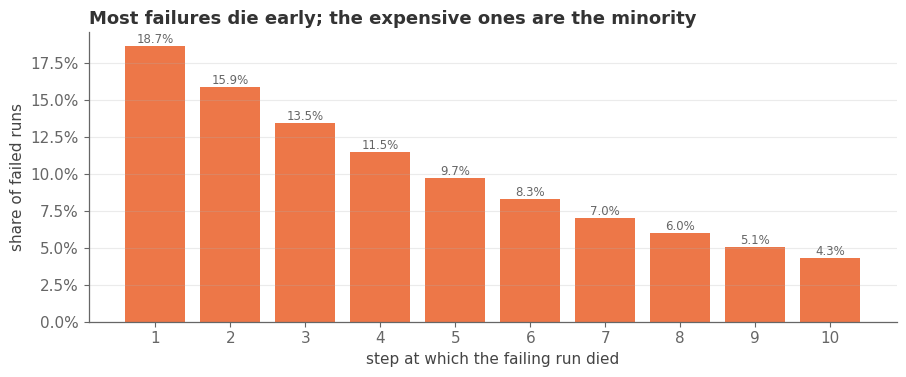

In [6]:
pe = effective_p(p, 'none')
die_at = np.array([pe ** i * (1 - pe) for i in range(n)])
die_at = die_at / die_at.sum()

fig, ax = plt.subplots(figsize=(9.2, 3.9))
bars = ax.bar(np.arange(1, n + 1), 100 * die_at, color=ORANGE, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', fontsize=8.5, color='#666666')
ax.set_xticks(np.arange(1, n + 1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('step at which the failing run died')
ax.set_ylabel('share of failed runs')
ax.set_title('Most failures die early; the expensive ones are the minority')
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0)
fig.tight_layout()

print(f"expected dying step, given failure: "
      f"{(die_at * np.arange(1, n + 1)).sum():.2f}")
print(f"failed runs dying at steps 8-10   : {die_at[7:].sum():.1%}")

The distribution decays geometrically: nearly a fifth of failed runs
never clear step one, and the average failure dies just past step
four. Most waste in an unmitigated pipeline is cheap waste. But the
tail matters: the 15% of failing runs that die in the last three steps
have spent nearly the full compute budget and delivered nothing.

Two practical corollaries fall out. First, monitor early steps hardest;
they generate the bulk of your failures. Second, and less obvious:
end-to-end success does not care about step order (a product is a
product), but the *cost of failure* does. If two orderings of your
pipeline are otherwise equivalent, put the fragile steps early, where
dying is cheap.

## A week of engineering: where should it go?

Real pipelines are not uniform, and the lab's live experiment found
exactly one failure class on clean documents: arithmetic. So here is a
profile shaped like that finding, strong extraction steps and two
weaker calculation steps, and the question every team eventually asks:
we have one block of engineering effort (a fine-tune, a prompt
rewrite, a better tool), which step should get it?

Model the effort honestly. A focused week of work does not add a fixed
number of points to any step you aim it at; going from 99% to 100% is
a research project while going from 90% to 95% is often a prompt fix.
What a block of effort tends to do is *cut the step's error rate by
some fraction*. So the fair comparison is: halve the error rate of
exactly one step, and watch the end-to-end number.

end-to-end success as-is: 0.748


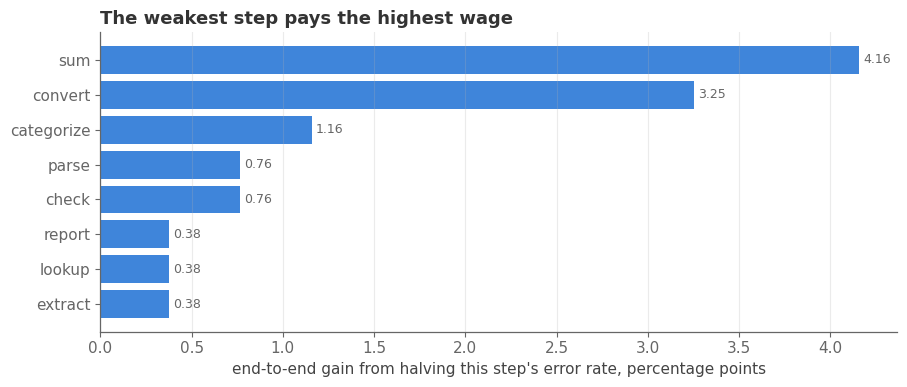

In [7]:
profile = {'extract': 0.99, 'parse': 0.98, 'categorize': 0.97,
           'lookup': 0.99, 'convert': 0.92, 'sum': 0.90,
           'check': 0.98, 'report': 0.99}

names = list(profile)
probs = np.array(list(profile.values()))
base = pipeline_chain(list(probs))
base_e2e = base.absorption_probabilities()[0, base.absorbing_states.index('done')]
print(f"end-to-end success as-is: {base_e2e:.3f}")

gains = []
for i, name in enumerate(names):
    improved = probs.copy()
    improved[i] = 1 - (1 - improved[i]) / 2       # halve this step's error
    c = pipeline_chain(list(improved))
    e2e = c.absorption_probabilities()[0, c.absorbing_states.index('done')]
    gains.append((name, probs[i], 100 * (e2e - base_e2e)))

gains = pd.DataFrame(gains, columns=['step', 'accuracy', 'gain']) \
          .sort_values('gain')

fig, ax = plt.subplots(figsize=(9.2, 4.0))
bars = ax.barh(gains['step'], gains['gain'], color=BLUE, alpha=0.9)
ax.bar_label(bars, fmt='%.2f', fontsize=9, color='#666666', padding=3)
ax.set_xlabel("end-to-end gain from halving this step's error rate, percentage points")
ax.set_title('The weakest step pays the highest wage')
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', alpha=0)
fig.tight_layout()

The ranking is strict and the gap is anything but subtle: halving the
error of the 90% summation step buys roughly eleven times the
end-to-end gain of the same treatment applied to a 99% extraction
step. The reason is simply room. Halving a 10% error rate recovers
five points of headroom; halving a 1% error rate recovers half a
point, because there was almost nothing left to fix.

One footnote, because the algebra is sneaky here. If you could
instead add a flat percentage point to any single step, the choice
would barely matter: a $+0.01$ bump multiplies the end-to-end rate by
$(p_i + 0.01) / p_i$, and with every $p_i$ close to 1 those factors
are nearly identical across steps. The order-of-magnitude leverage of
the weakest link comes entirely from where the *achievable* room
lives, not from any magic in the multiplication. Either way the
practical conclusion survives: improvement budgets should follow the
smallest diagonal.

## When the pipeline stops being a line

Everything so far had a closed form because a straight pipeline is the
simplest possible absorbing chain. One realistic wrinkle is enough to
end that. Suppose step 3 calls a flaky external tool, and when it
fails, the workflow does not die: it falls back to a cheaper backup
tool that succeeds 72% of the time, then rejoins the main path. Real
agent graphs are full of exactly this shape.

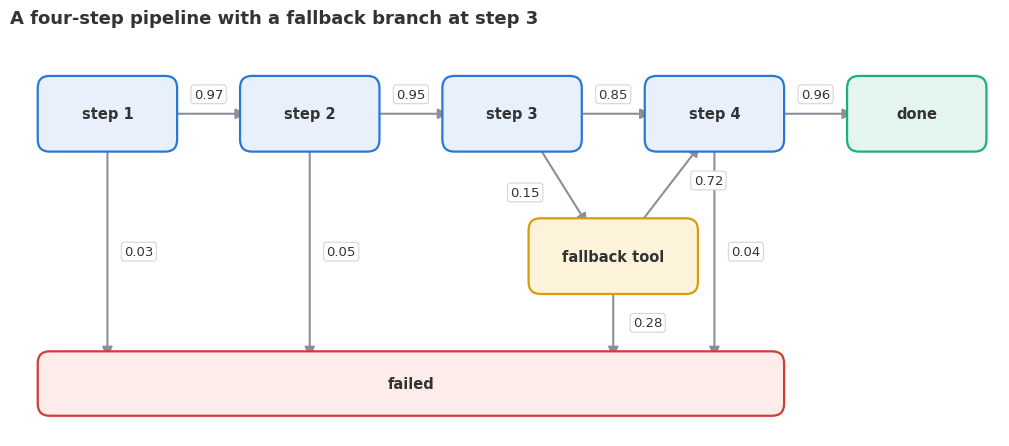

In [8]:
def add_box(ax, xy, w, text, face, edge, h=0.85):
    ax.add_patch(mpatches.FancyBboxPatch(
        (xy[0] - w / 2, xy[1] - h / 2), w, h,
        boxstyle='round,pad=0.08,rounding_size=0.16',
        facecolor=face, edgecolor=edge, lw=1.6, zorder=3))
    ax.annotate(text, xy=xy, ha='center', va='center', fontsize=10.5,
                fontweight='semibold', color=INK, zorder=4)

def add_arrow(ax, a, b, label=None, dx=0.0, dy=0.26):
    ax.add_patch(mpatches.FancyArrowPatch(
        a, b, arrowstyle='-|>', mutation_scale=15, lw=1.5,
        color=GRAY, shrinkA=0, shrinkB=0, zorder=2))
    if label:
        m = ((a[0] + b[0]) / 2 + dx, (a[1] + b[1]) / 2 + dy)
        ax.annotate(label, xy=m, ha='center', va='center', fontsize=9.5,
                    color=INK, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.22', facecolor='white',
                              edgecolor='#d5d5d5', lw=0.8))

fig, ax = plt.subplots(figsize=(11.5, 4.6))
xs = {'step 1': 0.0, 'step 2': 2.7, 'step 3': 5.4, 'step 4': 8.1,
      'done': 10.8}
for name, x in xs.items():
    if name == 'done':
        add_box(ax, (x, 0), 1.7, 'done', '#e3f5ec', GREEN)
    else:
        add_box(ax, (x, 0), 1.7, name, '#e8f1fb', BLUE)
add_box(ax, (6.75, -1.9), 2.1, 'fallback tool', '#fdf3da', '#d99b0b')
add_box(ax, (4.05, -3.6), 9.8, 'failed', '#fdecea', RED, h=0.7)

add_arrow(ax, (0.85, 0), (1.85, 0), '0.97')
add_arrow(ax, (3.55, 0), (4.55, 0), '0.95')
add_arrow(ax, (6.25, 0), (7.25, 0), '0.85')
add_arrow(ax, (8.95, 0), (9.95, 0), '0.96')
add_arrow(ax, (0.0, -0.43), (0.0, -3.25), '0.03', dx=0.42, dy=0)
add_arrow(ax, (2.7, -0.43), (2.7, -3.25), '0.05', dx=0.42, dy=0)
add_arrow(ax, (8.1, -0.43), (8.1, -3.25), '0.04', dx=0.42, dy=0)
add_arrow(ax, (5.75, -0.43), (6.4, -1.47), '0.15', dx=-0.5, dy=-0.1)
add_arrow(ax, (7.1, -1.47), (7.9, -0.43), '0.72', dx=0.52, dy=0.06)
add_arrow(ax, (6.75, -2.33), (6.75, -3.25), '0.28', dx=0.46, dy=0)

ax.set_xlim(-1.3, 11.9)
ax.set_ylim(-4.3, 1.1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('A four-step pipeline with a fallback branch at step 3', pad=6)
fig.tight_layout()

Try to write the end-to-end success rate of this graph as a clean
product. The run can reach "done" along two routes (step 3 succeeds, or
step 3 fails and the fallback rescues it), so the closed forms start
sprouting cases, and every additional branch multiplies them. This is
the moment the fundamental matrix stops being an elegant alternative
and becomes the only exact method in the room. Absorbing-chain
machinery never noticed the pipeline was straight; it digests the
branched transition matrix identically.

In [9]:
states = ['step1', 'step2', 'step3', 'fallback', 'step4', 'done', 'failed']
p1, p2, p3, pf, p4 = 0.97, 0.95, 0.85, 0.72, 0.96

P = np.zeros((7, 7))
P[0, 1] = p1; P[0, 6] = 1 - p1
P[1, 2] = p2; P[1, 6] = 1 - p2
P[2, 4] = p3; P[2, 3] = 1 - p3          # step 3 failure routes to fallback
P[3, 4] = pf; P[3, 6] = 1 - pf          # fallback rejoins, or fails for real
P[4, 5] = p4; P[4, 6] = 1 - p4
P[5, 5] = 1.0
P[6, 6] = 1.0

branched = AbsorbingChain(P, states)
Bb = branched.absorption_probabilities()
e2e = Bb[0, branched.absorbing_states.index('done')]
calls = branched.expected_cost([1, 1, 1, 1, 1])[0]

print(f"end-to-end success with the fallback   : {e2e:.4f}")
print(f"without it (0.97 * 0.95 * 0.85 * 0.96)  : {p1 * p2 * p3 * p4:.4f}")
print(f"expected model calls per run            : {calls:.3f}")

fractions, mean_steps = branched.simulate('step1', n_runs=50_000)
print(f"\nMonte Carlo check, 50k runs: {fractions['done']:.4f} success, "
      f"{mean_steps:.3f} mean steps")

end-to-end success with the fallback   : 0.8475
without it (0.97 * 0.95 * 0.85 * 0.96)  : 0.7519
expected model calls per run            : 3.913



Monte Carlo check, 50k runs: 0.8459 success, 3.911 mean steps


The fallback lifts end-to-end success by nearly ten percentage points
for a fraction of one extra call in expected cost, and the fifty
thousand simulated runs differ from the algebra only at the third
decimal, this series' usual two-witnesses rule. On a production agent graph
with twenty states and three fallback paths, simulation becomes noisy
and slow exactly when the graph becomes interesting, while the
fundamental matrix keeps returning exact answers instantly.

## Takeaways

1. A pipeline agent is an absorbing Markov chain, exactly: steps are
   transient states, outcomes are absorbing ones, mitigations are
   transition edits, and compute cost is notebook 02's visit-counting
   with a price per call.
2. Compounding is the enemy. Per-step rates that sound fine deliver
   end-to-end rates that are not, and the curve gets crueler with
   every step you add.
3. The chain view answers design questions, not just scoring
   questions: where failures die (early, mostly), and where the next
   block of engineering effort buys the most reliability (the weakest
   step, by roughly an order of magnitude).
4. Closed forms die at the first branch; the fundamental matrix does
   not care.
5. The empirical half of this argument, with a real local model, a
   failure taxonomy, and a verifier whose recall turned out to be the
   weak lever, lives in
   [agent-failure-lab](https://github.com/netsatsawat/agent-failure-lab).
   Between that repository and this notebook, the same numbers arrive
   by simulation, by measurement, and by algebra. When three roads
   meet at the same place, you can trust the destination.

One notebook remains. The same ledger, pointed at the other thing
every business worries about: the customer base, where the absorbing
states are "converted" and "churned" and the answers come out in
dollars.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*